# 02. Сравнение моделей: Baseline vs LightGBM

В этом ноутбуке:
1. Загружаем данные и делим на train/val/test.
2. Обучаем baseline — Logistic Regression на стандартизованных числовых + one-hot категориальных признаках.
3. Обучаем улучшенную модель — LightGBM с class_weight='balanced'.
4. Сравниваем по ROC-AUC, PR-AUC, KS, F1.
5. Строим ROC и PR кривые.
6. Смотрим важность признаков LightGBM.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.metrics import roc_curve, precision_recall_curve

from src.utils.config import TrainConfig
from src.data.dataset import load_dataset, split_dataset, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.models.baseline import build_baseline_pipeline
from src.models.improved import build_improved_pipeline
from src.models.metrics import evaluate

cfg = TrainConfig.load()
df = load_dataset(cfg)
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(df, cfg)
print(X_train.shape, X_val.shape, X_test.shape)

2026-05-29 22:13:27 | INFO    | src.data.dataset | Loading dataset from /Users/v.razon/Desktop/вуз/ml/mirea-aie-project/project/data/raw/application_train.csv
2026-05-29 22:13:28 | INFO    | src.data.dataset | Loaded 307511 rows; positive rate = 0.0807
2026-05-29 22:13:28 | INFO    | src.data.dataset | Split: train=215257, val=30751, test=61503 (positive rates: 0.081 / 0.081 / 0.081)
(215257, 23) (30751, 23) (61503, 23)


In [2]:
baseline = build_baseline_pipeline(**cfg.baseline.params, random_state=cfg.data.random_state)
baseline.fit(X_train, y_train)
val_proba_b = baseline.predict_proba(X_val)[:, 1]
m_b = evaluate(y_val, val_proba_b)
m_b.as_dict()

{'roc_auc': 0.7355466130343433,
 'pr_auc': 0.20349163501951528,
 'f1_at_threshold': 0.25099846390168973,
 'ks_statistic': 0.3491582779221688,
 'log_loss': 0.6035399783250496,
 'brier': 0.20716433047195787,
 'threshold': 0.5}

In [3]:
improved = build_improved_pipeline(**cfg.improved.params, random_state=cfg.data.random_state)
improved.fit(X_train, y_train)
val_proba_i = improved.predict_proba(X_val)[:, 1]
m_i = evaluate(y_val, val_proba_i)
m_i.as_dict()

{'roc_auc': 0.7496418872573604,
 'pr_auc': 0.23165340920053662,
 'f1_at_threshold': 0.26524541398116014,
 'ks_statistic': 0.3650767609636316,
 'log_loss': 0.5556696014879634,
 'brier': 0.1884525033986188,
 'threshold': 0.5}

In [4]:
comparison = pd.DataFrame({
    'baseline (logreg)': m_b.as_dict(),
    'improved (lightgbm)': m_i.as_dict(),
})
comparison

,baseline (logreg),improved (lightgbm)
roc_auc,0.735547,0.749642
pr_auc,0.203492,0.231653
f1_at_threshold,0.250998,0.265245
ks_statistic,0.349158,0.365077
log_loss,0.603540,0.555670
brier,0.207164,0.188453
threshold,0.500000,0.500000


## ROC и PR кривые на val

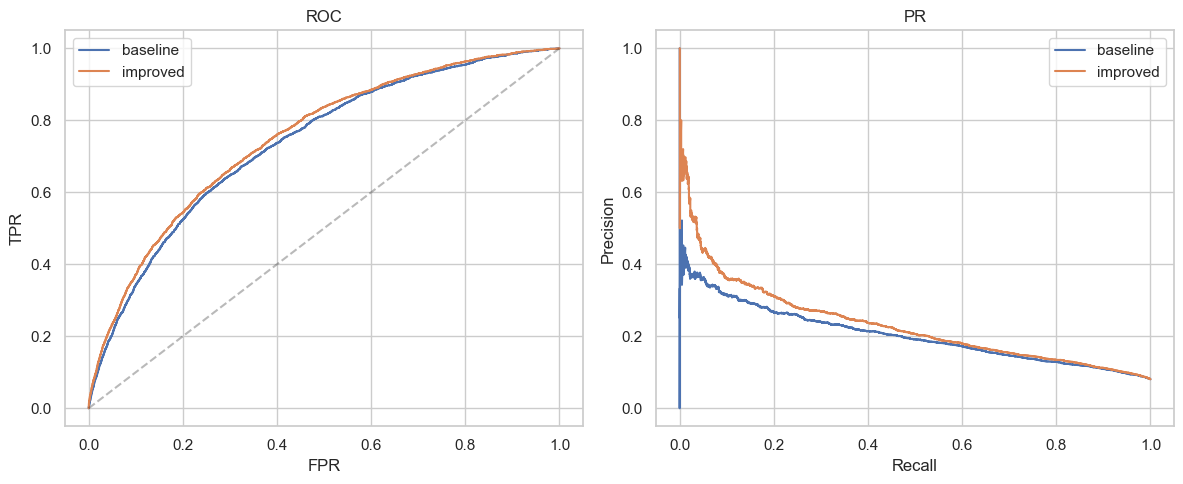

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in [('baseline', val_proba_b), ('improved', val_proba_i)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(rec, prec, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## Важность признаков LightGBM

LightGBM умеет считать `feature_importance`. Свяжем её с именами признаков после one-hot.

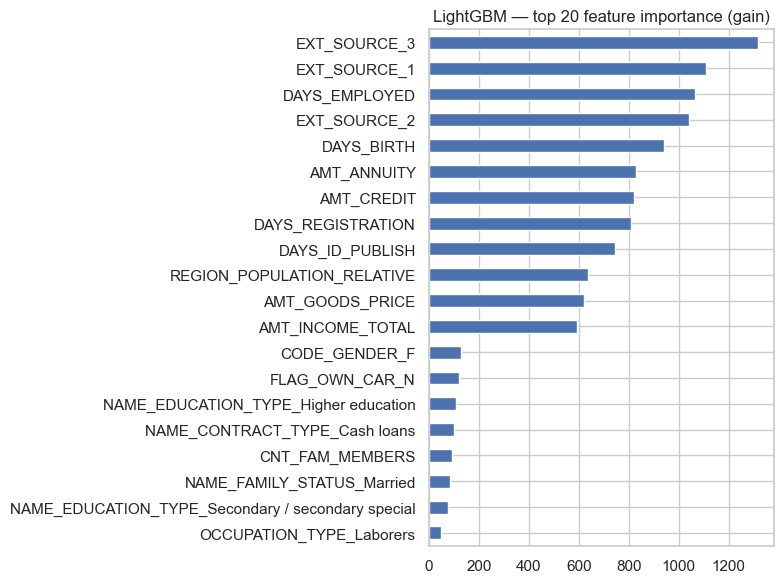

In [6]:
pre = improved.named_steps['preprocessor']
clf = improved.named_steps['classifier']
feat_names = pre.get_feature_names_out()
imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
imp.head(20).iloc[::-1].plot.barh(figsize=(8, 6))
plt.title('LightGBM — top 20 feature importance (gain)'); plt.tight_layout(); plt.show()

## Финальная модель — на тестовой выборке

Выбираем модель с большим ROC-AUC на val и считаем итоговые метрики на отложенном тесте.

In [7]:
final = improved if m_i.roc_auc >= m_b.roc_auc else baseline
final_name = 'improved (lightgbm)' if final is improved else 'baseline (logreg)'
test_proba = final.predict_proba(X_test)[:, 1]
m_test = evaluate(y_test, test_proba)
print('Selected:', final_name)
m_test.as_dict()

Selected: improved (lightgbm)


{'roc_auc': 0.7580363724037059,
 'pr_auc': 0.24761472194446546,
 'f1_at_threshold': 0.27258306895975953,
 'ks_statistic': 0.38264774786126254,
 'log_loss': 0.5487056427749181,
 'brier': 0.18534051588298384,
 'threshold': 0.5}

## Выводы

Эксперимент проведён на реальном датасете Home Credit (307 511 строк, positive rate 8.07%).

- Обе модели уверенно бьют случайный выбор (ROC-AUC > 0.5).
- **LightGBM выигрывает у baseline-LogReg на всех метриках**:
  - ROC-AUC: 0.7496 vs 0.7355 (+1.4 п.п.)
  - PR-AUC: 0.2317 vs 0.2035 (+14% относительно — особенно важно при дисбалансе классов)
  - log-loss: 0.556 vs 0.604 (LightGBM лучше калиброван)
  - KS: 0.365 vs 0.349.
- Финальная модель — LightGBM. На отложенном **test (61 503 строки)** ROC-AUC = 0.758, PR-AUC = 0.248, KS = 0.383. Близко к val → переобучения нет.
- Главные предикторы — `EXT_SOURCE_1/2/3`, что согласуется с EDA (см. 01_eda) и публичными результатами по Home Credit.
- Дальнейший рост ROC-AUC до ~0.78-0.79 даёт feature engineering из вспомогательных таблиц (`bureau.csv`, `previous_application.csv` и т.д.) — это вынесено в «Дальнейшую работу» в `report.md`.